# Anzahl Änderungen des Geschlechtseintrags nach Geschlecht, 10-Jahres-Altersklasse und Herkunft

### Kurzbeschreibung

Diese Daten beinhalten die Anzahl Änderungen des Geschlechtseintrags nach Geschlecht, 10-Jahres-Altersklasse und Herkunft.

Datum: 10.07.2024


Dataset auf PROD-Datakatalog: [Link]( https://data.stadt-zuerich.ch/dataset/bev_aege_jahr_herkunft_geschlecht_altersklasse_od3060)

Dataset auf INTEG-Datakatalog: [Link]( https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_aege_jahr_herkunft_geschlecht_altersklasse_od3060)


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [5]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [6]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [7]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [8]:
package_name = "bev_aege_jahr_herkunft_geschlecht_altersklasse_od3060"

In [9]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV306OD3060"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_aege_jahr_herkunft_geschlecht_altersklasse_od3060/download/BEV306OD3060.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_aege_jahr_herkunft_geschlecht_altersklasse_od3060 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_aege_jahr_herkunft_geschlecht_altersklasse_od3060 

data_source: web


In [10]:
data2betested.head(2).T

,0,1
StichtagDatJahr,2015-01-01 00:00:00,2015-01-01 00:00:00
SexBisherCd,1,1
SexBisherLang,männlich,männlich
SexBisherSort,1,1
SexCd,2,2
SexLang,weiblich,weiblich
SexSort,2,2
AlterV10Cd,30,50
AlterV10Lang,30- bis 39-Jährige,50- bis 59-Jährige
AlterV10Sort,4,6


Berechne weitere Attribute falls notwendig

In [11]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
SexBisherCd                     int64
SexBisherLang                  object
SexBisherSort                   int64
SexCd                           int64
SexLang                        object
SexSort                         int64
AlterV10Cd                      int64
AlterV10Lang                   object
AlterV10Sort                    int64
HerkunftCd                      int64
HerkunftLang                   object
HerkunftSort                    int64
AnzAeGe                         int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [12]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2015 und ein Maximumjahr von 2024


### Einfache Datentests

In [13]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 89 to 0
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      90 non-null     datetime64[ns]
 1   SexBisherCd          90 non-null     int64         
 2   SexBisherLang        90 non-null     object        
 3   SexBisherSort        90 non-null     int64         
 4   SexCd                90 non-null     int64         
 5   SexLang              90 non-null     object        
 6   SexSort              90 non-null     int64         
 7   AlterV10Cd           90 non-null     int64         
 8   AlterV10Lang         90 non-null     object        
 9   AlterV10Sort         90 non-null     int64         
 10  HerkunftCd           90 non-null     int64         
 11  HerkunftLang         90 non-null     object        
 12  HerkunftSort         90 non-null     int64         
 13  AnzAeGe              90 non-null     int64

In [14]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 90 rows (observations) and 17 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [15]:
data2betested.describe()

,StichtagDatJahr,SexBisherCd,SexBisherSort,SexCd,SexSort,AlterV10Cd,AlterV10Sort,HerkunftCd,HerkunftSort,AnzAeGe,Jahr,Jahr_nbr
count,90,90,90,90,90,90,90,90,90,90,90,90
mean,2020-10-27 15:44:00,1,1,2,2,28,4,1,1,3,2020-10-27 15:44:00,2021
min,2015-01-01 00:00:00,1,1,1,1,0,1,1,1,1,2015-01-01 00:00:00,2015
25%,2019-01-01 00:00:00,1,1,1,1,20,3,1,1,1,2019-01-01 00:00:00,2019
50%,2022-01-01 00:00:00,1,1,2,2,30,4,1,1,1,2022-01-01 00:00:00,2022
75%,2023-01-01 00:00:00,2,2,2,2,40,5,2,2,3,2023-01-01 00:00:00,2023
max,2024-01-01 00:00:00,2,2,2,2,70,8,2,2,20,2024-01-01 00:00:00,2024
std,NaN,0,0,0,0,16,2,0,0,3,NaN,3


Welches sind die Quartiere ohne Werte bei BEW?

In [16]:
data2betested[np.isnan(data2betested.AnzAeGe)]

,StichtagDatJahr,SexBisherCd,SexBisherLang,SexBisherSort,SexCd,SexLang,SexSort,...,HerkunftCd,HerkunftLang,HerkunftSort,AnzAeGe,StichtagDatJahr_str,Jahr,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [17]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [18]:
data2betested.index.year.unique()

Index([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [19]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [20]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,SexBisherCd,SexBisherSort,SexCd,SexSort,AlterV10Cd,AlterV10Sort,HerkunftCd,HerkunftSort,AnzAeGe,Jahr_nbr
count,90,90,90,90,90,90,90,90,90,90
mean,1,1,2,2,28,4,1,1,3,"2,021"
std,0,0,0,0,16,2,0,0,3,3
min,1,1,1,1,0,1,1,1,1,"2,015"
25%,1,1,1,1,20,3,1,1,1,"2,019"
50%,1,1,2,2,30,4,1,1,1,"2,022"
75%,2,2,2,2,40,5,2,2,3,"2,023"
max,2,2,2,2,70,8,2,2,20,"2,024"


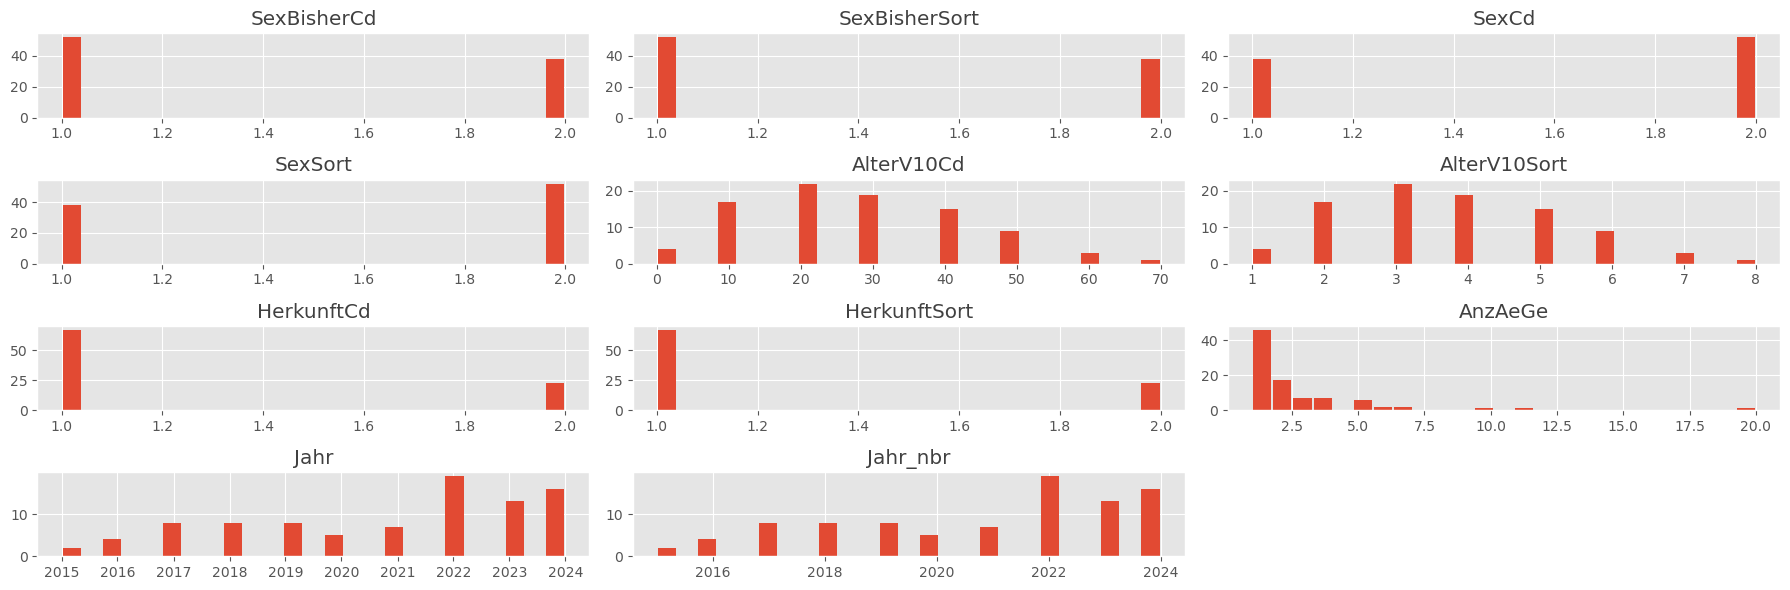

In [21]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [22]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,SexBisherCd,SexBisherLang,SexBisherSort,SexCd,SexLang,SexSort,AlterV10Cd,...,HerkunftCd,HerkunftLang,HerkunftSort,AnzAeGe,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [23]:
data2betested.isnull().sum()

SexBisherCd            0
SexBisherLang          0
SexBisherSort          0
SexCd                  0
SexLang                0
SexSort                0
AlterV10Cd             0
AlterV10Lang           0
AlterV10Sort           0
HerkunftCd             0
HerkunftLang           0
HerkunftSort           0
AnzAeGe                0
StichtagDatJahr_str    0
Jahr                   0
Jahr_nbr               0
dtype: int64

In [24]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [25]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzAeGe=('AnzAeGe', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,sum_AnzAeGe
0,2024-01-01,2024,48
1,2023-01-01,2023,40
2,2022-01-01,2022,78


In [26]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang']) \
    .agg(sum_AnzAeGe=('AnzAeGe', 'sum')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_herk.reset_index().head(3)

,HerkunftCd,HerkunftLang,sum_AnzAeGe
0,2,Ausländer*in,37
1,1,Schweizer*in,189


In [27]:
agg_zuz = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort']) \
    .agg(sum_AnzAeGe=('AnzAeGe', 'sum')) \
    .sort_values('AlterV10Sort', ascending=True) 
agg_zuz.reset_index().head(10)

,AlterV10Cd,AlterV10Lang,AlterV10Sort,sum_AnzAeGe
0,0,0- bis 9-Jährige,1,5
1,10,10- bis 19-Jährige,2,45
2,20,20- bis 29-Jährige,3,82
3,30,30- bis 39-Jährige,4,48
4,40,40- bis 49-Jährige,5,29
5,50,50- bis 59-Jährige,6,11
6,60,60- bis 69-Jährige,7,5
7,70,70- bis 79-Jährige,8,1


In [28]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['SexBisherLang', 'SexBisherSort', 'SexLang', 'SexSort',]) \
    .agg(sum_AnzAeGe=('AnzAeGe', 'sum')) \
    .sort_values('SexBisherSort', ascending=True) 
agg_age.reset_index().head(11)

,SexBisherLang,SexBisherSort,SexLang,SexSort,sum_AnzAeGe
0,männlich,1,weiblich,2,133
1,weiblich,2,männlich,1,93


### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [29]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,SexBisherCd,SexBisherLang,SexBisherSort,SexCd,SexLang,SexSort,AlterV10Cd,...,HerkunftCd,HerkunftLang,HerkunftSort,AnzAeGe,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,,
2024-01-01,1,männlich,1,2,weiblich,2,60,...,1,Schweizer*in,1,1,2024-01-01,2024-01-01,2024
2024-01-01,1,männlich,1,2,weiblich,2,10,...,1,Schweizer*in,1,4,2024-01-01,2024-01-01,2024


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Geschlechtsänderungen nach Geschlecht

In [30]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'SexBisherCd', 'SexBisherLang', 'SexBisherSort', 'SexCd', 'SexLang', 'SexSort', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzAeGe=('AnzAeGe', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,SexBisherCd,SexBisherLang,SexBisherSort,SexCd,SexLang,SexSort,StichtagDatJahr_str,Jahr,Jahr_nbr,sum_AnzAeGe
0,2015-01-01,1,männlich,1,2,weiblich,2,2015-01-01,2015-01-01,2015,2
1,2016-01-01,1,männlich,1,2,weiblich,2,2016-01-01,2016-01-01,2016,7
2,2017-01-01,1,männlich,1,2,weiblich,2,2017-01-01,2017-01-01,2017,8


In [31]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('SexSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_AnzAeGe:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "SexLang:N"
    ,category_beschriftung= 'Legende: Geschlecht neu'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung bei Änderungen des Geschlechts nach neuem Geschlecht, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [32]:
myAggBar=myAgg1
myAggBar.reset_index().columns

Index(['StichtagDatJahr', 'SexBisherCd', 'SexBisherLang', 'SexBisherSort', 'SexCd', 'SexLang',
       'SexSort', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr', 'sum_AnzAeGe'],
      dtype='object')

In [33]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

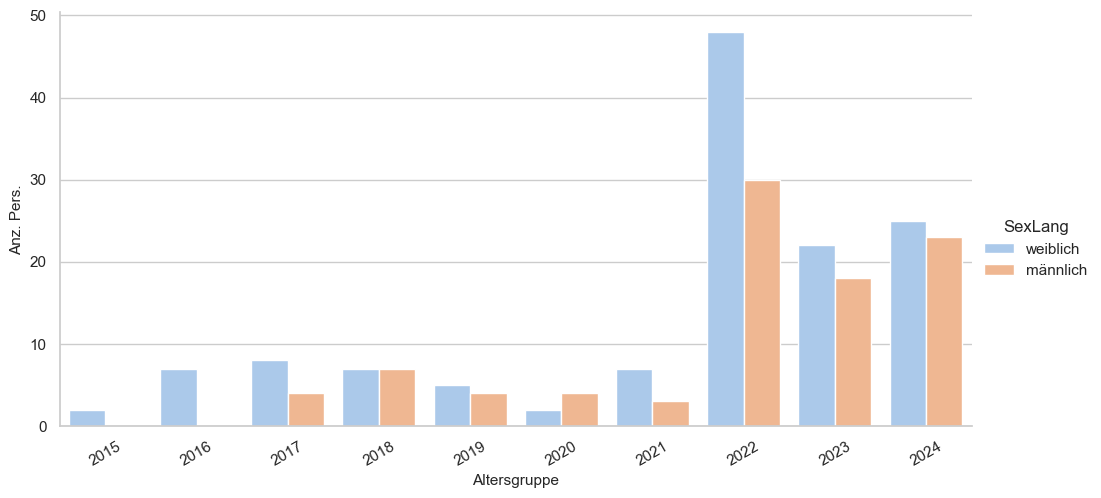

In [34]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Jahr_nbr"
            , y="sum_AnzAeGe"
            , hue="SexLang"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.reset_index()
           )
myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


#### Faced Grids

In [35]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myFG = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'SexBisherCd', 'SexBisherLang', 'SexBisherSort', 'SexCd', 'SexLang', 'SexSort', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort','StichtagDatJahr_str', 'Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzAeGe=('AnzAeGe', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myFG.reset_index().head(3)

,StichtagDatJahr,SexBisherCd,SexBisherLang,SexBisherSort,SexCd,SexLang,SexSort,AlterV10Cd,AlterV10Lang,AlterV10Sort,StichtagDatJahr_str,Jahr,Jahr_nbr,sum_AnzAeGe
0,2015-01-01,1,männlich,1,2,weiblich,2,30,30- bis 39-Jährige,4,2015-01-01,2015-01-01,2015,1
1,2015-01-01,1,männlich,1,2,weiblich,2,50,50- bis 59-Jährige,6,2015-01-01,2015-01-01,2015,1
2,2016-01-01,1,männlich,1,2,weiblich,2,10,10- bis 19-Jährige,2,2016-01-01,2016-01-01,2016,1


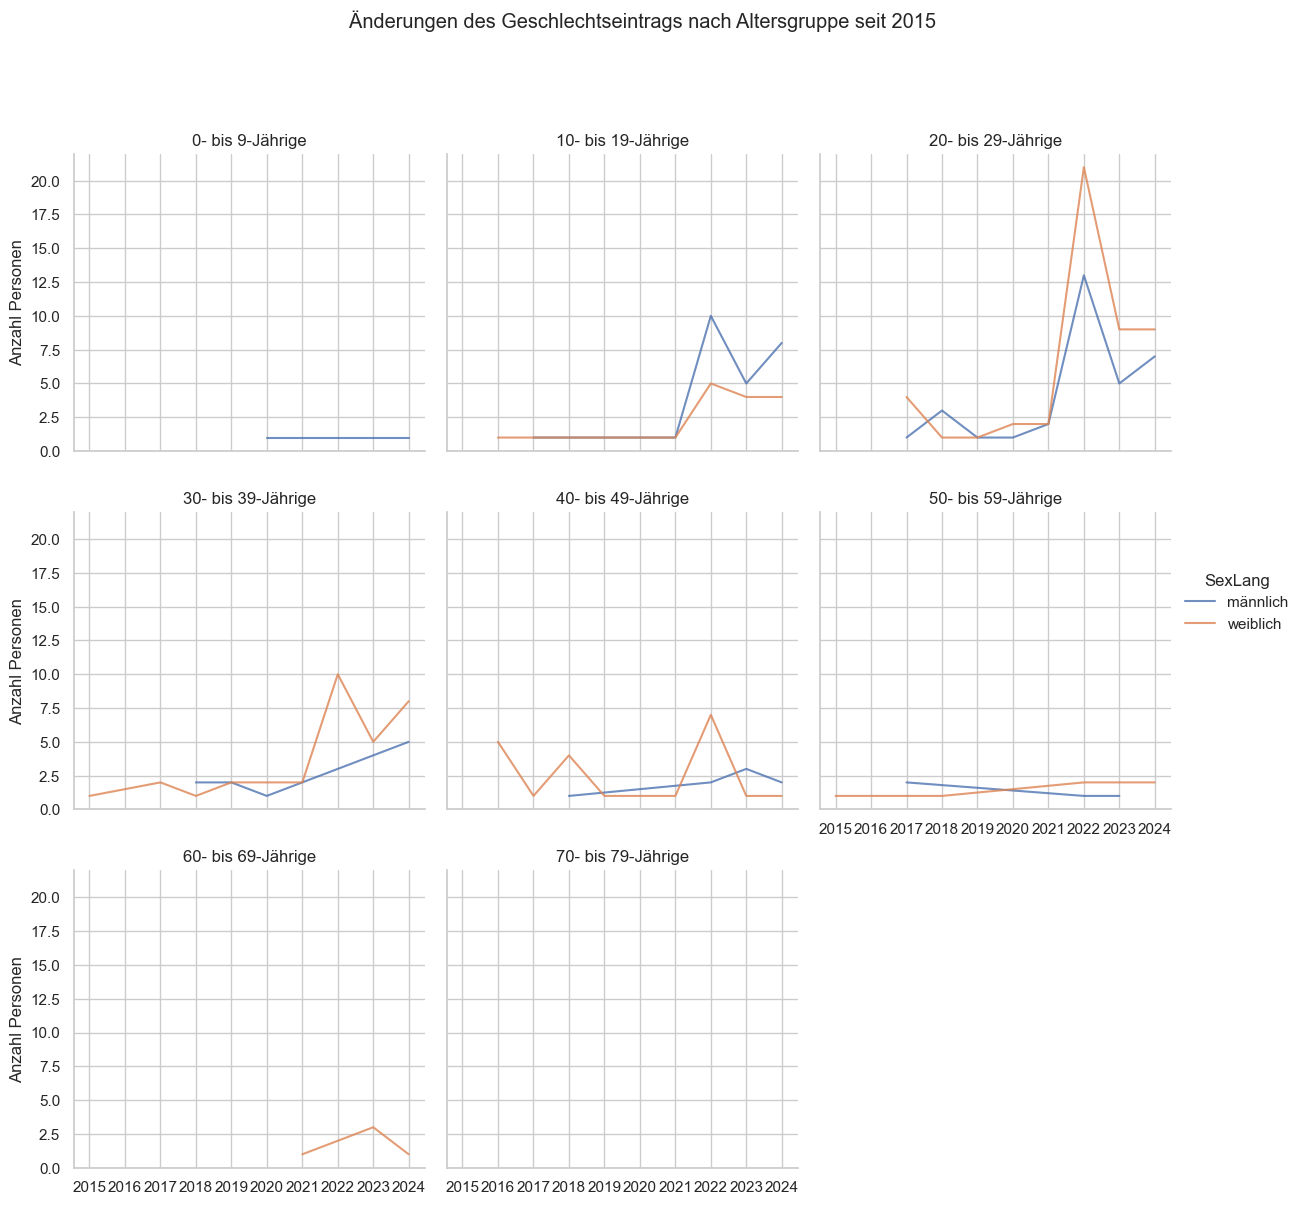

In [36]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('AlterV10Sort', ascending=True)
    ,col = "AlterV10Lang"
    ,hue = "SexLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_AnzAeGe"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Änderungen des Geschlechtseintrags nach Altersgruppe seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

In [37]:
myFG2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'SexBisherCd', 'SexBisherLang', 'SexBisherSort', 'SexCd', 'SexLang', 'SexSort', 'HerkunftCd', 'HerkunftLang', 'HerkunftSort','StichtagDatJahr_str', 'Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzAeGe=('AnzAeGe', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myFG2.reset_index().head(3)

,StichtagDatJahr,SexBisherCd,SexBisherLang,SexBisherSort,SexCd,SexLang,SexSort,HerkunftCd,HerkunftLang,HerkunftSort,StichtagDatJahr_str,Jahr,Jahr_nbr,sum_AnzAeGe
0,2015-01-01,1,männlich,1,2,weiblich,2,1,Schweizer*in,1,2015-01-01,2015-01-01,2015,2
1,2016-01-01,1,männlich,1,2,weiblich,2,1,Schweizer*in,1,2016-01-01,2016-01-01,2016,5
2,2016-01-01,1,männlich,1,2,weiblich,2,2,Ausländer*in,2,2016-01-01,2016-01-01,2016,2


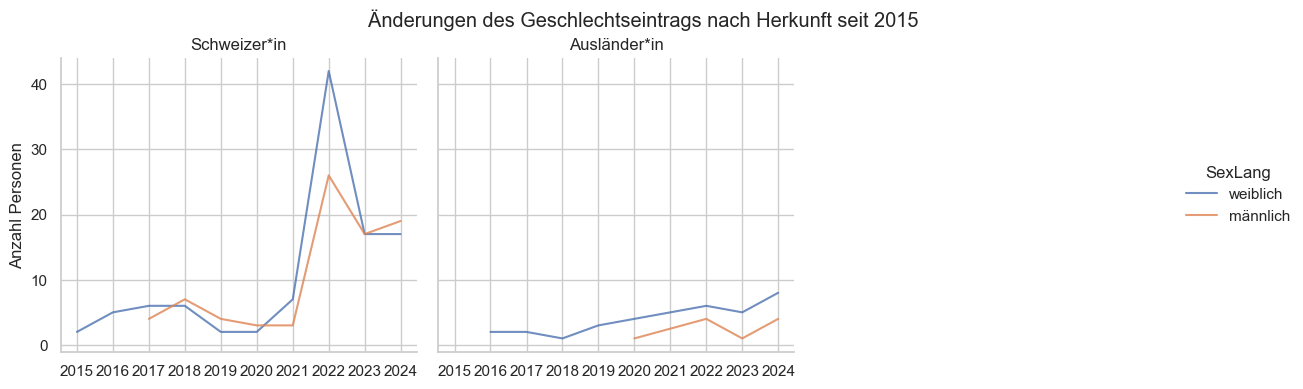

In [38]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = myFG2.reset_index().sort_values('HerkunftSort', ascending=True)
    ,col = "HerkunftLang"
    ,hue = "SexLang"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_AnzAeGe"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Änderungen des Geschlechtseintrags nach Herkunft seit "+str(int(data2betested.index.year.min()))
)
faced_grid2

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [39]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [40]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['AlterV10Lang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = div9ntr+qual12da+qual12br+qual12

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', '30- bis 39-Jährige': '#A30059', '50- bis 59-Jährige': '#DB247D', '40- bis 49-Jährige': '#FF579E', '10- bis 19-Jährige': '#FFA8D0', '20- bis 29-Jährige': '#E4E0DF', '0- bis 9-Jährige': '#A8DBB1', '60- bis 69-Jährige': '#55BC5D', '70- bis 79-Jährige': '#1F9E31'}


##### Änderungen des Geschlechtseintrags nach...

In [41]:
data2betested.columns

Index(['SexBisherCd', 'SexBisherLang', 'SexBisherSort', 'SexCd', 'SexLang', 'SexSort',
       'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort', 'HerkunftCd', 'HerkunftLang', 'HerkunftSort',
       'AnzAeGe', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [42]:
myTM = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'SexBisherCd', 'SexBisherLang', 'SexBisherSort', 'SexCd' 
    , 'SexLang', 'SexSort', 'AlterV10Cd', 'AlterV10Lang', 'AlterV10Sort'
    ,'HerkunftCd', 'HerkunftLang', 'HerkunftSort','StichtagDatJahr_str'
    , 'Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzAeGe=('AnzAeGe', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myTM.reset_index().head(3)

,StichtagDatJahr,SexBisherCd,SexBisherLang,SexBisherSort,SexCd,SexLang,SexSort,...,HerkunftCd,HerkunftLang,HerkunftSort,StichtagDatJahr_str,Jahr,Jahr_nbr,sum_AnzAeGe
0,2015-01-01,1,männlich,1,2,weiblich,2,...,1,Schweizer*in,1,2015-01-01,2015-01-01,2015,1
1,2015-01-01,1,männlich,1,2,weiblich,2,...,1,Schweizer*in,1,2015-01-01,2015-01-01,2015,1
2,2016-01-01,1,männlich,1,2,weiblich,2,...,1,Schweizer*in,1,2016-01-01,2016-01-01,2016,1


In [43]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['SexBisherLang', 'SexLang','AlterV10Lang','HerkunftLang','Jahr_nbr']
    ,values="sum_AnzAeGe"
    ,color="AlterV10Lang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=500
    ,width=1000               
    #,margin_val_bottom=25
    ,myHeaderTitle="Änderungen des Geschlechtseintrags nach Geschlecht bisher und neu, Altersgruppe und Herkunft seit, "+data_max_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001E382259F90>, 'SexBisherLang', 'SexLang', 'AlterV10Lang', 'HerkunftLang', 'Jahr_nbr']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1355)**

---------------------------------------------------------------------------